# Why a *joint* DMD cannot recover a shared parametric model

**A controlled demonstration with damped pendulums.**

We could ask using DMD, in effect, for evidence of a model that generalises across
individuals -- a single shared dynamical model, obtained either by a joint/global
DMD or by a quantitative mode-space comparison. This notebook shows, on a system
where the shared model is **known exactly**, why DMD is structurally the wrong
tool for that request.

We use five damped small-angle pendulums. They obey the *same* law
$\ddot\theta = -(g/L)\,\theta$ (with light damping); only the parameter $L$
differs, giving each a different frequency $\omega=\sqrt{g/L}$. This is
analoguous of the same kind of bird with an individual body size. Because the
system is linear, it is the best possible case for DMD: if a joint DMD
fails here, it cannot do better on real bird data.

We will show four things:

1. **(per)** Each pendulum *alone* → a single rank-2 decaying conjugate pair,
   reconstructed perfectly. The *same kind* of structure recurs at a different
   frequency — exactly what we observe across birds.
2. **(a)** A *joint* DMD with a shared low rank (rank 2) has one global
   spectrum, so it must commit to a single compromise frequency → it fits only
   the dominant pendulum and gets the rest badly wrong.
3. **(b)** To fit all five, the joint model needs rank $\approx 2N$ — it simply
   relearns the *union* of the individual frequencies. No shared low-rank model,
   and no recovery of the parameter $L$.
4. **(gen)** A joint model can fake a held-out sixth pendulum in-sample, but
   **diverges on extrapolation**, because its fixed spectrum contains no mode at
   the new frequency. A parametric ODE would generalise to any $L$; a fixed DMD
   spectrum cannot.

As a coda we show that time-rescaling each pendulum by its own frequency makes
the joint fit succeed, but only **circularly**, because the frequency match was
baked in by the alignment.

Throughout we use the paper's own engine: `pydmd`'s `BOPDMD` with Hankel
delay-embedding. The *null* that a mode-space comparison lacks is, here, the
known governing equation itself.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from pydmd.bopdmd import BOPDMD
from pydmd.preprocessing.hankel import hankel_preprocessing

EIG = {"conjugate_pairs"}  # same constraint the paper uses


def make_pendulums(freqs_hz, amps, phases, gamma, t):
    """theta_i(t) = A_i exp(-gamma_i t) cos(2 pi f_i t + phi_i).  (n_pend, n_t)."""
    w = 2 * np.pi * np.asarray(freqs_hz)
    return np.array(
        [
            a * np.exp(-g * t) * np.cos(wi * t + p)
            for a, g, wi, p in zip(amps, gamma, w, phases, strict=True)
        ]
    )


def fit_dmd(data, t, rank, d=4):
    """Hankel-preprocessed BOPDMD. data (n_vars, n_t). Returns (dmd, recon, gt)."""
    dmd = hankel_preprocessing(BOPDMD(svd_rank=rank, eig_constraints=EIG), d=d)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dmd.fit(data, t=t[d - 1 :])
    recon = np.real(dmd.reconstructed_data)
    m = min(recon.shape[1], data.shape[1])
    return dmd, recon[:, :m], data[:, :m]


def rrmse(a, b):
    """Relative RMSE (normalised by signal RMS)."""
    return float(np.sqrt(np.mean((a - b) ** 2)) / (np.sqrt(np.mean(a**2)) + 1e-12))


def freqs_of(dmd):
    f = np.sort(np.abs(np.imag(dmd.eigs)) / (2 * np.pi))
    return f[f > 0.1]

## The five pendulums

Same law, five different lengths → five frequencies spanning the range of hawk
wingbeat frequencies, with light damping (a decaying oscillation, like the
observed wingbeat) and individual amplitudes/phases.

In [3]:
dt = 0.005  # like the paper's bin size
t = np.arange(0, 1.2, dt)
freqs = [3.5, 4.0, 4.5, 5.0, 5.5]  # Hz — spread like wingbeat across birds
amps = [1.0, 0.8, 1.2, 0.9, 1.1]
phases = [0.0, 0.4, 0.9, 1.3, 1.8]
gamma = [0.45, 0.50, 0.40, 0.55, 0.48]  # light damping

X = make_pendulums(freqs, amps, phases, gamma, t)  # (5, n_t)
n_pend = X.shape[0]
print(f"True frequencies (Hz): {freqs}")
print(f"data shape {X.shape}, dt={dt}, window={t[-1]:.2f}s")

True frequencies (Hz): [3.5, 4.0, 4.5, 5.0, 5.5]
data shape (5, 240), dt=0.005, window=1.20s


## (per) Each pendulum alone: the same structure recurs

Fit each pendulum *individually* with a rank-2 model. Each is reconstructed to
machine precision and its frequency recovered exactly. The same *kind* of mode
(one decaying oscillatory pair) recurs across all five — at different
frequencies. This is the interpretable recurrence we report for the birds; it
does **not** require, or imply, a single shared operator.

In [4]:
for i in range(n_pend):
    dmd, rec, gt = fit_dmd(X[i : i + 1], t, rank=2)
    print(
        f"  pendulum {i} (true {freqs[i]} Hz): rRMSE={rrmse(gt[0], rec[0]):.4f}  "
        f"recovered f={np.round(freqs_of(dmd), 2)}"
    )

  pendulum 0 (true 3.5 Hz): rRMSE=0.0000  recovered f=[3.5 3.5]
  pendulum 1 (true 4.0 Hz): rRMSE=0.0000  recovered f=[4. 4.]
  pendulum 2 (true 4.5 Hz): rRMSE=0.0000  recovered f=[4.5 4.5]
  pendulum 3 (true 5.0 Hz): rRMSE=0.0000  recovered f=[5. 5.]
  pendulum 4 (true 5.5 Hz): rRMSE=0.0000  recovered f=[5.5 5.5]


## (a) & (b) A joint model: compromise, or relearn the union

Now fit **one** DMD model to all five pendulums together (a 5-dimensional
observation: each pendulum is one component, all sharing a single global
spectrum). Sweep the rank.

- At **rank 2** the model has a single conjugate pair (one frequency for all
  five) so it locks onto the dominant pendulum and the other four are almost
  entirely unfit (relative error near 1).
- The reconstruction only becomes accurate at **rank 10 = 2N**, where the
  recovered frequencies are exactly the *union* of the five individual
  frequencies. The joint model has not discovered a shared structure or the
  parameter $L$; it has simply concatenated five separate pendulums. The rank
  grows with the number of individuals.

In [5]:
ranks = [2, 4, 6, 8, 10, 12]
sweep = {}
for rank in ranks:
    dmd, rec, gt = fit_dmd(X, t, rank=rank)
    per = np.array([rrmse(gt[i], rec[i]) for i in range(n_pend)])
    sweep[rank] = (per, freqs_of(dmd), rec, gt)
    print(
        f"  rank {rank:2d}: per-pendulum rRMSE={np.round(per, 3)}  "
        f"mean={per.mean():.3f}  recovered f={np.round(freqs_of(dmd), 2)}"
    )

  rank  2: per-pendulum rRMSE=[0.981 0.981 0.201 0.975 0.975]  mean=0.822  recovered f=[4.48 4.48]
  rank  4: per-pendulum rRMSE=[0.964 0.835 0.141 0.473 0.324]  mean=0.547  recovered f=[4.5  4.5  5.35 5.35]
  rank  6: per-pendulum rRMSE=[0.225 0.42  0.076 0.393 0.228]  mean=0.268  recovered f=[3.62 3.62 4.53 4.53 5.38 5.38]
  rank  8: per-pendulum rRMSE=[0.032 0.096 0.059 0.099 0.028]  mean=0.063  recovered f=[3.53 3.53 4.22 4.22 4.76 4.76 5.47 5.47]
  rank 10: per-pendulum rRMSE=[0. 0. 0. 0. 0.]  mean=0.000  recovered f=[3.5 3.5 4.  4.  4.5 4.5 5.  5.  5.5 5.5]
  rank 12: per-pendulum rRMSE=[0. 0. 0. 0. 0.]  mean=0.000  recovered f=[ 3.5   3.5   4.    4.    4.5   4.5   5.    5.    5.5   5.5  79.27 79.27]


## (gen) A joint model does not generalise to a new individual

Take a held-out sixth pendulum with a *new* length (frequency 4.7 Hz, absent
from the training set). Give the joint model every advantage: fix only its
spectrum (from the rank-10 fit on the other five) and let the amplitudes be fit
freely. Fit those amplitudes on the first 60% of the signal, then **extrapolate**.

In-sample the joint spectrum can *fake* the new pendulum almost perfectly (by
beating nearby frequencies), but on extrapolation it diverges — it has no mode
at 4.7 Hz. The pendulum's *own* rank-2 model, which captured the right
frequency, extrapolates flawlessly. A parametric ODE would generalise to any
$L$; a fixed DMD spectrum cannot.

In [6]:
f6 = 4.7
x6 = make_pendulums([f6], [1.0], [0.5], [0.47], t)[0]
k = int(0.6 * len(t))
t_fit = t[:k]

# joint spectrum (fixed) from the other five; free amplitudes
dmd10, _, _ = fit_dmd(X, t, rank=10)
eigs = dmd10.eigs
coef, *_ = np.linalg.lstsq(np.exp(np.outer(eigs, t_fit)).T, x6[:k], rcond=None)
x6_joint = np.real(coef @ np.exp(np.outer(eigs, t)))

# the sixth's OWN rank-2 model
d6, _, _ = fit_dmd(x6[None, :k], t_fit, rank=2)
co, *_ = np.linalg.lstsq(np.exp(np.outer(d6.eigs, t_fit)).T, x6[:k], rcond=None)
x6_own = np.real(co @ np.exp(np.outer(d6.eigs, t)))

print(f"held-out f6={f6} Hz; fit on first {k} samples, extrapolate {len(t) - k}")
print(
    f"  JOINT spectrum: in-window rRMSE={rrmse(x6[:k], x6_joint[:k]):.4f}  "
    f"EXTRAPOLATION rRMSE={rrmse(x6[k:], x6_joint[k:]):.4f}"
)
print(
    f"  OWN rank-2 fit: in-window rRMSE={rrmse(x6[:k], x6_own[:k]):.4f}  "
    f"EXTRAPOLATION rRMSE={rrmse(x6[k:], x6_own[k:]):.4f}"
)
print(f"  joint spectrum freqs: {np.round(freqs_of(dmd10), 2)}  (no {f6} Hz)")

held-out f6=4.7 Hz; fit on first 144 samples, extrapolate 96
  JOINT spectrum: in-window rRMSE=0.0007  EXTRAPOLATION rRMSE=0.2152
  OWN rank-2 fit: in-window rRMSE=0.0000  EXTRAPOLATION rRMSE=0.0000
  joint spectrum freqs: [3.5 3.5 4.  4.  4.5 4.5 5.  5.  5.5 5.5]  (no 4.7 Hz)


## (circ) Time-rescaling makes it 'work' — circularly

If we first rescale each pendulum's time by its *own* frequency, all five
collapse onto $\cos\tau$ and a rank-2 joint fit succeeds. But this success is
circular: the shared frequency was imposed by the alignment, not discovered.
This is precisely the caveat attached to the $\tau$-aligned joint DMD of the
birds — recovering a wingbeat at $\tau=1$ is true by construction.

In [7]:
n_cyc, n_tau = 4.0, 200
tau = np.linspace(0, n_cyc, n_tau)
Xr = np.zeros((n_pend, n_tau))
for i in range(n_pend):
    ti = (tau / freqs[i])[(tau / freqs[i]) <= t[-1]]
    Xr[i, : len(ti)] = np.interp(ti, t, X[i])
_, recr, gtr = fit_dmd(Xr, tau, rank=2)
per_r = np.array([rrmse(gtr[i], recr[i]) for i in range(n_pend)])
print(f"rank-2 joint fit on tau-aligned data: per-pendulum rRMSE={np.round(per_r, 3)}")
print(f"mean rRMSE={per_r.mean():.3f}  (good — but circular: alignment used each omega)")

rank-2 joint fit on tau-aligned data: per-pendulum rRMSE=[0.029 0.025 0.016 0.008 0.018]
mean rRMSE=0.019  (good — but circular: alignment used each omega)


## Summary figure

saved figures/15_pendulum_joint_dmd.{svg,png}


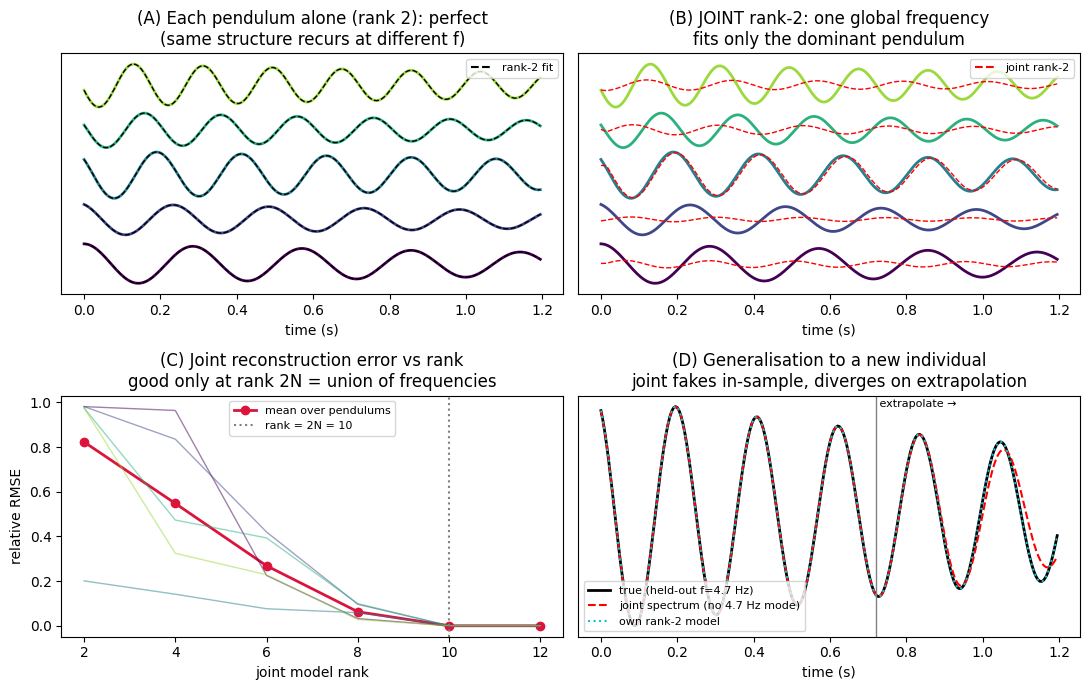

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
colors = plt.cm.viridis(np.linspace(0, 0.85, n_pend))

# (A) per-pendulum perfect fits
for i in range(n_pend):
    _, rec, gt = fit_dmd(X[i : i + 1], t, rank=2)
    ax[0, 0].plot(t[: gt.shape[1]], gt[0] + 2.2 * i, color=colors[i], lw=2)
    ax[0, 0].plot(t[: rec.shape[1]], rec[0] + 2.2 * i, "k--", lw=1)
ax[0, 0].set_title("(A) Each pendulum alone (rank 2): perfect\n(same structure recurs at different f)")
ax[0, 0].set_xlabel("time (s)"); ax[0, 0].set_yticks([])
ax[0, 0].plot([], [], "k--", label="rank-2 fit"); ax[0, 0].legend(loc="upper right", fontsize=8)

# (B) joint rank-2 compromise
per2, _, rec2, gt2 = sweep[2]
for i in range(n_pend):
    ax[0, 1].plot(t[: gt2.shape[1]], gt2[i] + 2.2 * i, color=colors[i], lw=2)
    ax[0, 1].plot(t[: rec2.shape[1]], rec2[i] + 2.2 * i, "r--", lw=1)
ax[0, 1].set_title("(B) JOINT rank-2: one global frequency\nfits only the dominant pendulum")
ax[0, 1].set_xlabel("time (s)"); ax[0, 1].set_yticks([])
ax[0, 1].plot([], [], "r--", label="joint rank-2"); ax[0, 1].legend(loc="upper right", fontsize=8)

# (C) rRMSE vs rank
means = [sweep[r][0].mean() for r in ranks]
ax[1, 0].plot(ranks, means, "o-", color="crimson", lw=2, label="mean over pendulums")
for i in range(n_pend):
    ax[1, 0].plot(ranks, [sweep[r][0][i] for r in ranks], color=colors[i], alpha=0.5, lw=1)
ax[1, 0].axvline(2 * n_pend, color="grey", ls=":", label=f"rank = 2N = {2 * n_pend}")
ax[1, 0].set_title("(C) Joint reconstruction error vs rank\ngood only at rank 2N = union of frequencies")
ax[1, 0].set_xlabel("joint model rank"); ax[1, 0].set_ylabel("relative RMSE")
ax[1, 0].legend(fontsize=8)

# (D) generalisation by extrapolation
ax[1, 1].plot(t, x6, color="k", lw=2, label="true (held-out f=4.7 Hz)")
ax[1, 1].plot(t, x6_joint, "r--", lw=1.5, label="joint spectrum (no 4.7 Hz mode)")
ax[1, 1].plot(t, x6_own, color="tab:cyan", ls=":", lw=1.5, label="own rank-2 model")
ax[1, 1].axvline(t[k], color="grey", ls="-", lw=1)
ax[1, 1].text(t[k], ax[1, 1].get_ylim()[1] * 0.9, " extrapolate →", fontsize=8)
ax[1, 1].set_title("(D) Generalisation to a new individual\njoint fakes in-sample, diverges on extrapolation")
ax[1, 1].set_xlabel("time (s)"); ax[1, 1].set_yticks([]); ax[1, 1].legend(fontsize=8, loc="lower left")

fig.tight_layout()
fig.savefig("figures/15_pendulum_joint_dmd.svg", bbox_inches="tight")
fig.savefig("figures/15_pendulum_joint_dmd.png", dpi=150, bbox_inches="tight")
print("saved figures/15_pendulum_joint_dmd.{svg,png}")

## What this means for the hawk analysis

The pendulums are a known parametric *family*: one law, one knob ($L$). Yet:

- DMD describes each individual **perfectly** with the same *kind* of
  low-dimensional mode — the structure recurs, which is interpretable and real.
- A **joint/global DMD** cannot express "same law, different parameter". It
  either compromises to a single spectrum (and fits only one individual) or
  inflates its rank to the union of all individual spectra (no shared model, no
  recovered parameter), and it fails to generalise to a new individual.
- The $\tau$-aligned joint fit "works" only circularly.

DMD returns a **fixed spectrum**; a model that generalises across individuals
needs the parameter as a *knob*, which DMD does not have. This is why neither a
joint DMD nor a mode-space distance yields the interpretable, rigorous
cross-individual *model* Reviewer 1 is reaching for — and why we instead ground
the recurrence claim in interpretable physical invariants observed across the
individual fits (the $\approx 2{:}1$ frequency ratio present in every bird; the
shared kinematic signatures of the gliding-transition mode).